# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **Preparation**

このセクションでは前のChapterの内容を読み込むだけです。<br>
コードを実行するだけでOK。読まなくても大丈夫です。<br>
気軽に先へ進んでください。<br>

In [ ]:
# ファイルをダウンロードしてください
!wget https://raw.githubusercontent.com/HayatoHongo/EveryonesLLM/main/input.txt -O input.txt
# utf-8でダウンロードしたinput.textファイルを読み込む。
with open("input.txt", 'r', encoding = 'utf-8') as f:
    text = f.read()

# テンソルを見やすく表示する関数（任意）
import torch
import torch.nn as nn
import torch.nn.functional as F

# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# Pytorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor


--2025-11-08 10:53:36--  https://raw.githubusercontent.com/HayatoHongo/EveryonesLLM/main/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.007s  

2025-11-08 10:53:36 (153 MB/s) - ‘input.txt’ saved [1115394/1115394]



# **Chapter 16: モデルサイズだけ大きくする**



### **Section 1: `Trainer`クラスの改良**

Google Colab では無料のT4 GPUが提供されています。利用しましょう。

In [ ]:
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'  # 使用デバイス（GPUまたはCPU）
print(device_type)

cuda


**`Check Point`**  
<label><input type="checkbox">ランタイムがcuda(GPU)に設定されていることを確認した<br></label>  

#### モデルを大きくして「loss plateau」を突破してみる

前回は、約20万パラメータの**とても小さなモデル**を使い、約110万文字ほどの**小規模なShakespeareデータセット**（`input.txt`）で学習を行いました。

ところが、どれだけ計算資源をつぎ込んでも、**検証誤差（val loss）が1.7〜1.8あたりで停滞**してしまいました。

このように、損失が下がらなくなる状態を「**loss plateau（損失の停滞）**」と呼びます。

そこで今回は、**モデルのサイズを大きくする方向に計算資源を使ってみます。**

一般的に、**パラメータ数が多い大きなモデルの方が表現力が高く、loss plateauの位置も下がる**ことが期待できるからです。


#### 学習時間と処理トークンの可視化

今回の学習は、**およそ50分**かかります。
学習が進むにつれて、**モデルが処理するトークンの総数**もどんどん増えていきます。

そこで、学習の進行状況をよりわかりやすくするために、
各ステップ時点での以下の情報を記録するようにしました。

* その時点までに**学習で使われたトークンの総数**を表す `total_seen_tokens`
* その時点までの **累計学習時間（秒）** を表す `total_train_time`

これらの値を保持するために、`Trainer` クラスに対応する変数とリストを追加しています。


🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`[]`　`()`

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        ########## NEW ##########
        self.total_seen_tokens_list = []
        self.total_train_time_list = []
        ########## NEW ##########

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

In [ ]:
"""
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        ########## NEW ##########
        # 学習過程で「これまでに処理したトークン数」を記録するリスト
        self.total_seen_tokens_list = __  # TODO: FILL
        # 学習にかかった累計時間を記録するリスト
        self.total_train_time_list = __ # TODO: FILL
        ########## NEW ##########

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}
  """

'\nimport time\n\nclass Trainer:\n    def __init__(self, model, optimizer, data_loader, config):\n        self.model = model\n        self.optimizer = optimizer\n        self.data_loader = data_loader\n        self.config = config\n\n        self.steps = []\n        self.train_losses = []\n        self.val_losses = []\n        ########## NEW ##########\n        # 学習過程で「これまでに処理したトークン数」を記録するリスト\n        self.total_seen_tokens_list = __  # TODO: FILL\n        # 学習にかかった累計時間を記録するリスト\n        self.total_train_time_list = __ # TODO: FILL\n        ########## NEW ##########\n\n    def train_step(self):\n        # トレーニング用バッチを取得。\n        input_batch, target_batch = self.data_loader.get_batch(\'train\')\n        self.optimizer.zero_grad()\n\n        # モデルの順伝播と損失計算\n        logits, loss = self.model(input_batch, target_batch)\n        loss.backward()  # 誤差逆伝播\n        self.optimizer.step()  # パラメータ更新\n\n        return loss.item() # 損失の値を返す\n\n    def evaluate(self):\n        self.model.eval()  # 評

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        ########## NEW ##########
        self.total_seen_tokens_list = []
        self.total_train_time_list = []
        ########## NEW ##########

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}
```

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`1`　`0`　`interval_from_last_eval`　`last_eval_end_time`　`self.config.batch_size`　`step`　`append`　`logits`　`self.config.total_steps`　`evaluation_interval`

In [ ]:
# Trainer クラスのつづき
def train(self):
    # configで指定された回数だけtrain_stepを実行する。
    total_train_time = 0
    last_eval_end_time = time.time()
    for step in range(1, self.config.total_steps + 1):

        # 100回ごと、または最終ステップのみ評価する。
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_steps:
            # step == self.config.evaluation_frequency は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。
            current_eval_start_time = time.time()
            evaluation_interval = current_eval_start_time - last_eval_end_time
            total_train_time += evaluation_interval
            tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
            tokens_per_second = tokens_per_evaluation_interval / evaluation_interval if evaluation_interval > 0 else 0
            eval_loss = self.evaluate()

            ########## NEW ##########
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            ########## NEW ##########

            ########## NEW ##########
            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second)} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )
            ########## NEW ##########

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            ########## NEW ##########
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)
            ########## NEW ##########

            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()

In [ ]:
"""
# Trainer クラスのつづき
def train(self):
    # configで指定された回数だけtrain_stepを実行する。
    total_train_time = 0
    last_eval_end_time = time.time()
    for step in range(1, self.config.total_steps + 1):
        # 100回ごと、または最終ステップのみ評価する。
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_steps:
            # step == self.config.evaluation_frequency は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。
            current_eval_start_time = time.time()
            evaluation_interval = current_eval_start_time - last_eval_end_time
            total_train_time += evaluation_interval
            tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
            tokens_per_second = tokens_per_evaluation_interval / evaluation_interval if evaluation_interval > 0 else 0
            eval_loss = self.evaluate()

            ########## NEW ##########
            # これまでに処理したトークン数を計算
            total_seen_tokens = ________________ * self.config.input_sequence_length * _____ # TODO: FILL
            ########## NEW ##########

            ########## NEW ##########
            # step、損失、処理速度(tok/s)、トークン数、経過時間をまとめて出力
            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second)} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )
            ########## NEW ##########

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])

            ########## NEW ##########
            # 記録用リストに累計トークン数と経過時間を追加
            self.total_seen_tokens_list.______(total_seen_tokens) # TODO: FILL
            self.total_train_time_list.append(total_train_time)
            ########## NEW ##########

            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()
  """

'\ndef train(self):\n    # configで指定された回数だけtrain_stepを実行する。\n    for step in range(1, self.config.total_steps + 1):\n        # 100回ごと、または最終ステップのみ評価する。\n        if step % self.config.evaluation_frequency == 0 or step == self.config.total_steps:\n            # step == self.config.evaluation_frequency は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。\n            if step == self.config.evaluation_frequency or step == self.config.total_steps:\n              tokens_per_second = None\n              ########## NEW ##########\n              if step == self.config.evaluation_frequency:\n                # 最初の評価ではまだ経過時間がないため、累計時間を初期化する。\n                total_train_time = __ # TODO: FILL\n              else: # step == self.config.total_steps\n                # 最終ステップでは最後の評価からの経過時間を加算\n                current_time = time.time()\n                interval_from_last_eval = current_time - _____________ # TODO: FILL\n                total_train_time += ______________ # TODO: FILL\n              #

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
def train(self):
    # configで指定された回数だけtrain_stepを実行する。
    for step in range(1, self.config.total_steps + 1):

        # 100回ごと、または最終ステップのみ評価する。
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_steps:
            # step == self.config.evaluation_frequency は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。
            if step == self.config.evaluation_frequency or step == self.config.total_steps:
              tokens_per_second = None
              ########## NEW ##########
              # 最初のステップ
              if step == self.config.evaluation_frequency:
                total_train_time = 0
              # 最終ステップ
              else:
                current_time = time.time()
                interval_from_last_eval = current_time - last_eval_end_time
                total_train_time += interval_from_last_eval
              ########## NEW ##########
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              ########## NEW ##########
              total_train_time += evaluation_interval
              ########## NEW ##########
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()

            ########## NEW ##########
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            ########## NEW ##########

            ########## NEW ##########
            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )
            ########## NEW ##########

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            ########## NEW ##########
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)
            ########## NEW ##########

            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()

        # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()
```

🔧 クラスメソッド追加・差し替えの公式

```python
def 新しい関数(self, ...):
    ...

既存クラス.メソッド名 = 新しい関数
```

In [ ]:
Trainer.train = train

`train`関数が長くなり、特に`if`文が増えて読みづらくなっています。
可読性を上げるため、リファクタリングを行います。

具体的には、条件分岐を減らすために「最後のステップ」と「評価ステップ」を揃えます。

学習ループは最初から次のように1始まりで記述します。

```python
for step in range(1, self.config.total_steps + 1):
```

これにより、`step`は `1`〜`total_steps` となり、`train_step`は設定どおり`total_steps`回実行されます。例えば、`total_steps = 1000`、`evaluation_frequency = 100` の場合、最終ステップ`1000`が評価タイミングと一致します。

最終ステップと評価ステップが揃うため、条件分岐を簡素にできます。

※`total_steps`が`evaluation_frequency`の倍数でない場合（例：1050と100）は適用できませんが、通常は問題ありません。


🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`self.config.total_steps`　`self.config.total_steps+1`　`1`　`0`

In [ ]:
def new_train(self):
    # configで指定された回数だけtrain_stepを実行する。)
    ########## NEW ##########
    total_train_time = 0
    last_eval_end_time = time.time()
    for step in range(1, self.config.total_steps + 1): # TODO: FILL
    ########## NEW ##########
        # 100回ごとに評価する。
        ########## NEW ##########
        if step % self.config.evaluation_frequency == 0:
            ########## NEW ##########

            ########## NEW ##########
            # 最初のステップ
            current_eval_start_time = time.time()
            evaluation_interval = current_eval_start_time - last_eval_end_time
            total_train_time += evaluation_interval
            tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
            tokens_per_second = tokens_per_evaluation_interval / evaluation_interval if evaluation_interval > 0 else 0
            eval_loss = self.evaluate()
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second)} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()

In [ ]:
"""
def new_train(self):
    # configで指定された回数だけtrain_stepを実行する。)
    ########## NEW ##########
    for step in range(____________________________): # TODO: FILL
    ########## NEW ##########
        # 100回ごとに評価する。
        ########## NEW ##########
        if step % self.config.evaluation_frequency == 0:
            ########## NEW ##########

            ########## NEW ##########
            # 最初のステップ
            if step == __:  # TOOD: FILL
              tokens_per_second = 0
              total_train_time = 0
            ########## NEW ##########

            # 2回目以降の評価ステップ（最終ステップ含む）
            else:
            current_eval_start_time = time.time()
            evaluation_interval = current_eval_start_time - last_eval_end_time
            total_train_time += evaluation_interval
            tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
            tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second)} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()
"""

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
def new_train(self):
    # configで指定された回数だけtrain_stepを実行する。)
    ########## NEW ##########
    for step in range(1, self.config.total_steps + 1): # TODO: FILL
    ########## NEW ##########
        # 100回ごとに評価する。
        ########## NEW ##########
        if step % self.config.evaluation_frequency == 0:
        ########## NEW ##########

            ########## NEW ##########
            # 最初のステップ
            if step == self.config.evaluation_frequency:  # TOOD: FILL
              tokens_per_second = None
              total_train_time = 0
            ########## NEW ##########

            # 2回目以降の評価ステップ（最終ステップ含む）
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              total_train_time += evaluation_interval
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()

        # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()
  ```

🔧 クラスメソッド追加・差し替えの公式

```python
def 新しい関数(self, ...):
    ...

既存クラス.メソッド名 = 新しい関数
```

* **メソッド名はそのまま**（`train()` で呼べる）
* **中身だけ置き換わる**（`new_train` の処理が実行される）
<br>

In [ ]:
Trainer.train = new_train # TODO: ヒント: 難しく考えないでください。とてもシンプルです。

**Section 1: `Trainer`クラスの改良** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: LLMの過学習**

`Dataloader`クラスとモデルクラスを定義します。Chpater12と完全に同じです。

In [ ]:
class DataLoader:
    def __init__(self, text, config):
        self.config = config  # 設定オブジェクト
        chars = sorted(list(set(text)))  # ユニークな文字をソートする
        self.ctoi = {char: index for index, char in enumerate(chars)}
        self.itoc = {index: char for index, char in enumerate(chars)}

        # エンコードしてテンソルに変換する。
        # `__init__`外のメソッドや引数を呼ぶには`self.`が必要です。
        self.data = torch.tensor(self.encode(text), dtype=torch.long)

        # 訓練用と検証用に分割する。
        # 引数が指定されなくてもself.dataが使われます。
        self.train_data, self.val_data = self.split_data()

    def encode(self, text):
        # 文字列をインデックス列に変換します。self.で他のメソッドや引数を呼び出します。
        return [self.ctoi[c] for c in text]

    def decode(self, indices):
        return ''.join([self.itoc[i] for i in indices])

    def split_data(self):
        split_index = int(0.9 * len(self.data))  # データの90%を訓練用に分割するポイント。
        return self.data[:split_index], self.data[split_index:]

    def get_batch(self, split):
        data = self.train_data if split == 'train' else self.val_data
        start_indices = torch.randint(len(data) - self.config.input_sequence_length, (self.config.batch_size,)) # 抽出開始インデックスを生成する

        input_sequences = torch.stack([
            data[start_index:start_index + self.config.input_sequence_length]
            for start_index in start_indices
        ])
        target_sequences = torch.stack([
            data[start_index + 1:start_index + self.config.input_sequence_length + 1]
            for start_index in start_indices
        ])
        return input_sequences.to(self.config.device_type), target_sequences.to(self.config.device_type)

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = config.vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        attention_weights = F.softmax(masked_attention_weights, dim=-1)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)


    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        output = projected

        return output


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output


class VocabularyLogits(nn.Module):
    def __init__(self, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, config.vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


def generate_stream(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -model.config.input_sequence_length:]
            logits, _ = model(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] / temperature

            if top_k is not None:
                values, _ = torch.topk(last_logits, min(top_k, last_logits.size(-1)))
                last_logits = last_logits.masked_fill(last_logits < values[:, [-1]], float('-inf'))

            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(last_logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = False
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                last_logits = last_logits.masked_fill(indices_to_remove, float('-inf'))

            probs = F.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_indices = torch.cat((input_indices, next_token), dim=1)
            yield input_indices


def generate(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    generated_indices = input_indices
    for generated_indices in generate_stream(
        model,
        input_indices,
        max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    ):
        pass
    return generated_indices

class nanoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.embedding = EmbeddingModule(config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(config=config)
        self.criterion = nn.CrossEntropyLoss()

    # テキストを生成する
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

#### 🦖 モデルサイズを大幅に拡大

今回の実験では、**モデルのスケールを一気に引き上げます。**

| パラメータ                   | 変更前 | 変更後      | 倍率 | 説明                           |
| ----------------------- | --- | -------- | -- | ---------------------------- |
| 埋め込み次元（`embedding_dim`） | 64  | **512**  | ×8 | トークンをより高次元で表現し、表現力を強化        |
| 隠れ次元（`hidden_dim`）      | 256 | **2048** | ×8 | 埋め込みの4倍とし、モデル内部の情報処理能力を拡大    |


また、各ヘッドの次元を64として、512 ÷ 64 = 8 よりアテンションヘッドの数は8とします。


In [ ]:
# モデル設定を保存する設定クラス
class Config:
    batch_size = 16
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    vocab_size = 65
    total_steps = 10_000  # おおよそ1分くらいかかる
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    learning_rate = 0.001  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    ########## NEW ##########
    embedding_dim = 512  # 埋め込み層サイズ（特徴ベクトルの次元数）
    hidden_dim = 2048
    num_attention_heads = 8  # アテンションヘッドの数
    ########## NEW ##########
    layer_count = 4  # モデルの層数
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = Config()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

In [ ]:
# データを読み込む
with open("input.txt", 'r', encoding = 'utf-8') as f:
    text_data = f.read()
data_loader = DataLoader(text_data, config)

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

モデル全体のパラメータ数は約0.24Mから12.9Mへと、
**およそ50倍**に大幅アップしました。

| 指標     | 変更前    | 変更後        | 増加率      |
| ------ | ------ | ---------- | -------- |
| パラメータ数 | 約0.24M | **約12.9M** | **約50倍** |

埋め込みや隠れ層の拡張によって、
モデルはより多くの情報を内部で保持・学習できるようになります。


In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

12.933185 M parameters


### 🚀 学習スタート！

いよいよ学習を開始します。
モデルサイズが大きくなった分、**1ステップあたりの計算負荷も増加**しています。

今回は **15 GB RAM の T4 GPU** を使用し、
`batch size = 16`、`total steps = 10,000` の設定で進めます。

この条件だと、**学習完了までにおよそ50分**ほどかかります😇

A100 40GB RAM の方は、およそ15~20分を見込んでください。

正直、かなりヒマです…。遊んでください。

よかったらこちらの動画でもどうぞ👇（なお3分だけ）

🎬 [I built ChatGPT with Minecraft redstone!](https://youtu.be/VaeI9YgE1o8?si=8nQ4fQaSx6HP4iWF)

In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===
step 00000 | train loss 4.3219 | val loss 4.3275 | tok/s None | tokens 0 | time 0.00s
step 00100 | train loss 2.4815 | val loss 2.5023 | tok/s 28593 | tokens 819,200 | time 28.65s
step 00200 | train loss 2.4664 | val loss 2.4969 | tok/s 28325 | tokens 1,638,400 | time 57.57s
step 00300 | train loss 2.4401 | val loss 2.4825 | tok/s 27345 | tokens 2,457,600 | time 87.53s
step 00400 | train loss 2.4280 | val loss 2.4774 | tok/s 27396 | tokens 3,276,800 | time 117.43s
step 00500 | train loss 2.3833 | val loss 2.4609 | tok/s 26759 | tokens 4,096,000 | time 148.04s
step 00600 | train loss 2.3184 | val loss 2.3672 | tok/s 27065 | tokens 4,915,200 | time 178.31s
step 00700 | train loss 2.1886 | val loss 2.2633 | tok/s 27041 | tokens 5,734,400 | time 208.61s


KeyboardInterrupt: 

横軸を`Step`、縦軸を`Loss`として`matplotlib`を使って描画しましょう。

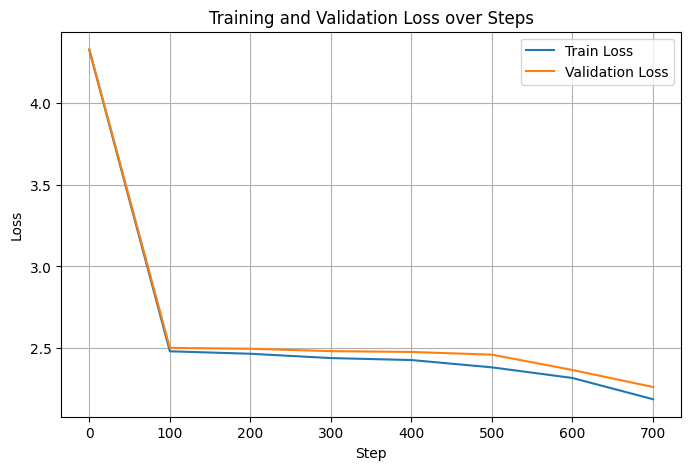

In [ ]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')
plt.plot(trainer.steps, trainer.val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

#### loss plateau は下がったが、過学習の兆候も

今回の学習では、検証誤差（validation loss）が約1.5まで下がりました！

前回の1.7〜1.8付近と比べると、確かにloss plateau（損失の停滞点）が下がったのが分かります。

……が、よく見ると学習の後半で**検証誤差がむしろ上がり始め**、**訓練誤差との差がどんどん広がって**います。

---

これはまさに、**過学習（overfitting）** の典型的なパターンです。

---

このまま学習を続けると、訓練誤差はほぼ0に近づき、モデルは訓練データをそのまま再現してしまいます。

つまり、「一言一句を丸暗記してしまった状態」になるわけです。それはそれですごいですけどね笑

<br>

今回使っているShakespeareデータセットは、わずか約110万文字（≒110万トークン前後）で小さなままです。

それに対して、モデルのパラメータ数を 約24万 → 約1,200万（約50倍） と、大幅に増やしています。

このアンバランスさが原因で、**モデルがデータを“覚えすぎてしまう”** 状況になっています。
さらに、学習全体で処理したトークンの総数（`total_seen_tokens`）は**約8,000万トークン**にもなります。
サンプリングの開始位置は約100万トークン分しかないので、ランダムにサンプリングしているとはいえ、
**全く同じ文章を何十回もサンプリングしている**計算になります。


In [ ]:
# 推論もやってみる
model.eval()
print("Model set to eval mode")

In [ ]:
prompt = "Let's he"
print(f"\n入力プロンプト: {prompt}")

# トークナイズしてテンソル化
encoded = data_loader.encode(prompt) # テキストをIDにエンコード
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
print_formatted_tensor(encoded_tensor)


入力プロンプト: Let's he
encoded [24, 43, 58, 5, 57, 1, 46, 43]
Tensor Size: [8]
tensor([
         24.00,  43.00,  58.00,   5.00,  57.00,   1.00,  46.00,  43.00
       ])
Tensor Size: [1, 8]
tensor([
         [ 24.00,  43.00,  58.00,   5.00,  57.00,   1.00,  46.00,  43.00]
       ])
Tensor Size: [1, 8]
tensor([
         [ 24.00,  43.00,  58.00,   5.00,  57.00,   1.00,  46.00,  43.00]
       ])


In [ ]:
# テキスト生成
generated_text = generate(model, encoded_tensor, max_new_tokens=512)

In [ ]:
decoded_text = data_loader.decode(generated_text[0].tolist())
print(decoded_text)

Let's here he unterothes themy thy ar gn
Whall vignts fres theever conthe groumand amay, afften: now sh sher trintrock, soufthus
a dattichem ilichisland'd ckinsinshavescongse seet wor ath anso you. Yen pe yown


Cimetizect MANENou th his toour, gaike,
And's rmivess wecowe, s, m'st red kis to,
And,
The in Kit ses upood cheing, this de?
ING VIVIVICARET:
keade h nd! athow! Ju, to ine Yor, st chat inds y f gl frethan ay theaiga h ameamanthally hecrd?

Ser ustodley las ix his
amsentat ago s k ard f ds
'd beshapt ORK:
By


スペルはほぼ完璧ですね。過学習したモデルなので出力の多様性には欠けますが。

**Section 2: LLMの過学習** <label><input type="checkbox"> Mark as Done</label>

### **Section 3: Google Driveへの保存**

今回はT4 GPUをたっぷり使って学習してるので、学習ログはきちんと保管しましょう。

おすすめはGoole Driveです。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 学習済み trainer からログをまとめる
results = {
    "step": trainer.steps,
    "train_loss": trainer.train_losses,
    "val_loss": trainer.val_losses,
    "total_seen_tokens": trainer.total_seen_tokens_list,
    "total_train_time": trainer.total_train_time_list,
}

print(results)

{'step': [0, 100, 200, 300, 400, 500, 600, 700], 'train_loss': [4.3219249725341795, 2.481521201133728, 2.4664280652999877, 2.4400654077529906, 2.4280304193496702, 2.3833382606506346, 2.3183768033981322, 2.1885696172714235], 'val_loss': [4.327525091171265, 2.502288293838501, 2.496890687942505, 2.4824543237686156, 2.477354907989502, 2.46087167263031, 2.367189908027649, 2.2633102416992186], 'total_seen_tokens': [0, 819200, 1638400, 2457600, 3276800, 4096000, 4915200, 5734400], 'total_train_time': [0, 28.650230884552002, 57.571067333221436, 87.5279221534729, 117.42910671234131, 148.04282689094543, 178.31046843528748, 208.60511946678162]}


```python
関数: pd.DataFrame
引数: results（辞書やリストなどのデータ構造）
```


In [ ]:
import pandas as pd
# pandas の DataFrame に変換
df = pd.DataFrame(results) # TODO: 関数(引数)

In [ ]:
df

,step,train_loss,val_loss,total_seen_tokens,total_train_time
0,0,4.321925,4.327525,0,0.000000
1,100,2.481521,2.502288,819200,28.650231
2,200,2.466428,2.496891,1638400,57.571067
3,300,2.440065,2.482454,2457600,87.527922
4,400,2.428030,2.477355,3276800,117.429107
5,500,2.383338,2.460872,4096000,148.042827
6,600,2.318377,2.367190,4915200,178.310468
7,700,2.188570,2.263310,5734400,208.605119


```python
関数: os.makedirs
引数: dir_path, exist_ok=True
```

* `os.makedirs(dir_path)`は、指定したパスのディレクトリを作成します。
* `exist_ok=True`を指定することで、すでにフォルダが存在していてもエラーにならずにスキップされます。


In [ ]:
# 保存先のフォルダを作成する
import os
dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter16" # TODO: 関数(引数)
os.makedirs(dir_path, exist_ok=True)

In [ ]:
# csvファイルとして保存する先のパスを指定する。
save_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter16/training_logs.csv"

```python
インスタンス: df（pandasのDataFrame）
メソッド: to_csv
引数: save_path, index=False
```

* `df.to_csv(save_path, index=False)` により、`df`の内容をCSVファイルとして保存します。
* `index=False` を指定すると、DataFrameの行番号（インデックス）はCSVに書き込まれません。

In [ ]:
# CSVとして保存
df.to_csv(save_path, index=False) # TODO: インスタンス.メソッド(引数)
print(f"✅ CSV saved to: {save_path}")

✅ CSV saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter16/training_logs.csv


#### 📂 ログファイルの確認方法

[Google Drive](https://drive.google.com/drive/u/0/home) を開いて確認してください。

作成したフォルダ **`nanoGPT_logs/Chapter16`** の中に、
CSV形式のログファイルが作成されているはずです。

---

⚠️ **注意：**
Google Drive のマウントに失敗したまま進めると、
フォルダやファイルは`drive`という名前の **Colab のローカル環境** のフォルダに保存されます。Google Drive上にはありません。

その場合は再度Driveをマウントしてください。

---


**`Check Point`** <label><input type="checkbox">Google Drive上のcsvファイルを確認した<label>

次に、モデル情報を記したconfigインスタンスについても、config.jsonとして保存しましょう。

```python
関数: vars
引数: config.__class__
```

* `vars(config.__class__)` は、`config` インスタンスのクラス（`config.__class__`）が持つ属性を辞書形式で取得します。
* `vars` は `__dict__` にアクセスするための推奨される組み込み関数です。
* 結果として、`{属性名: 属性値, ...}` という形式の辞書が得られます。

In [ ]:
# クラス属性を辞書化
config_class_dict = vars(config.__class__) # TODO: 関数(引数)
print(config_class_dict)

```python
元の変数: config_class_dict
メソッド: items
引数：なし

新しい変数 = 元の変数.メソッド(引数)
```

* `.items()` を使うことで、クラス属性の名前（キー）とその値を1つずつ処理できる形式になる。


In [ ]:
# 辞書の (key, value) ペアを取得
config_dict_items = config_class_dict.items() # TODO: 新しい変数 = 元の変数.メソッド(引数)
print(config_dict_items)

`__module__`という余計なキーが混ざっているので、除去します。

1から書くのは大変なので、タイピングするだけでいいです。

```python
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
}
```

In [ ]:
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
} # TODO:

print(config_dict)

```python
関数: os.path.join
引数: dir_path, "model_config.json"
```

* `os.path.join()` は、複数のパス要素を結合して、プラットフォームに依存しないファイルパスを作成する関数。
* たとえば Windows では `\`、Unix系では `/` を使ってパスを正しく構築してくれます。
* この場合、`dir_path` ディレクトリ内の `"model_config.json"` ファイルへのパスを作成。

In [ ]:
# 保存先のファイルパスを作成する。
# dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter16"
config_path = os.path.join(dir_path, "model_config.json") # TODO: 関数(引数)
print(config_path)

/content/drive/MyDrive/nanoGPT_logs/Chapter16/model_config_.json


```python
関数: json.dump
引数: config_dict, f
```

* `config_dict` をファイル `f` に JSON形式で書き込み。

In [ ]:
import json
# ファイルを「書き込みモード(w)」で開き、変数`f`で操作できるようにする
with open(config_path, "w") as f:
    json.dump(config_dict, f) # TODO: 関数(引数)

print(f"✅ Config saved to: {config_path}")

✅ Config saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter16/model_config_.json


**Section 3: Google Driveへの保存** <label><input type="checkbox"> Mark as Done</label>

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**`Chapter 16: モデルサイズだけ大きくする`** <label><input type="checkbox"> Mark as Done</label>